In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r"C:\Users\CompuMarts\Downloads\Final_graduation_VoiceSystem\DATA_voice_control.csv")
df.head()

,Voice,Intent
0,يمين,right
1,اتحرك يمين,right
2,امشي يمين,right
3,إلى اليمين,right
4,يا كرسي تحرك يمين,right


In [4]:
df.rename(columns={'Voice':'Sentence', 'Intent':'Class'}, inplace=True)
df.head()

,Sentence,Class
0,يمين,right
1,اتحرك يمين,right
2,امشي يمين,right
3,إلى اليمين,right
4,يا كرسي تحرك يمين,right


In [ ]:
df.reset_index(inplace=True)

In [ ]:
df.drop('index',axis=1,inplace=True)

In [5]:
df.head()

,Sentence,Class
0,يمين,right
1,اتحرك يمين,right
2,امشي يمين,right
3,إلى اليمين,right
4,يا كرسي تحرك يمين,right


In [6]:
df.isna().sum()

Sentence    0
Class       0
dtype: int64

In [7]:
df.dropna(inplace=True)
df.shape

(99, 2)

In [8]:
df.duplicated().sum()

np.int64(2)

In [9]:
df.drop_duplicates(inplace=True)
df.shape

(97, 2)

In [10]:
x=df.drop('Class',axis=1)
y=df['Class']
x.head()


,Sentence
0,يمين
1,اتحرك يمين
2,امشي يمين
3,إلى اليمين
4,يا كرسي تحرك يمين


In [11]:
y.head()

0    right
1    right
2    right
3    right
4    right
Name: Class, dtype: object

In [12]:
from sklearn.preprocessing import LabelEncoder
LB=LabelEncoder()
y=LB.fit_transform(y)
y

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3])

In [13]:
LB.classes_

array(['down', 'left', 'right', 'stop', 'up'], dtype=object)

In [14]:
CLASS_NAMES = LB.classes_
NUM_CLASSES = len(CLASS_NAMES)

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.10,
                                                    random_state=42,stratify=y) # encoded_matrix
print("X_train : \n",X_train)
print("X_test  : \n",X_val)
print(y_train)
print(y_val)

X_train : 
              Sentence
95                بطل
1          اتحرك يمين
54         إلى الشمال
98       يا كرسي توقف
32     طير إلى الامام
..                ...
4   يا كرسي تحرك يمين
61                خلف
41         اتحرك شمال
5         تحرك يميناً
88                اقف

[87 rows x 1 columns]
X_test  : 
            Sentence
6   تحرك إلى اليمين
22        اجري قدام
73      ارجع للوراء
69      تحرك للوراء
93          لا ترجع
8           لف يمين
81             توقف
39             شمال
33       امشي قدامك
40             يسار
[3 2 1 3 4 0 2 0 1 3 3 1 2 3 2 0 3 0 1 0 0 3 1 4 4 3 4 2 2 3 3 2 1 0 1 1 0
 4 3 4 4 4 2 2 1 4 3 0 0 2 4 3 4 3 1 1 2 2 4 2 1 1 3 2 4 1 0 0 1 4 0 1 4 1
 4 0 3 0 0 0 4 3 2 0 1 2 3]
[2 4 0 0 3 2 3 1 4 1]


In [16]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# سحب النصوص من الـ DataFrame عشان التوكنايزر يقدر يتعامل معاها
train_texts = X_train['Sentence'].astype(str).tolist()
val_texts = X_val['Sentence'].astype(str).tolist()

# تعريف التوكنايزر وتدريبه على داتا التدريب
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_texts)

# تحويل الكلمات لأرقام
X_train_seq = tokenizer.texts_to_sequences(train_texts)
X_val_seq = tokenizer.texts_to_sequences(val_texts)

# حساب حجم القاموس وأطول جملة لتوحيد الطول (Padding)
vocab_size = len(tokenizer.word_index) + 1
max_length = max([len(seq) for seq in X_train_seq]) 

# توحيد طول المصفوفات
X_train_padded = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_val_padded = pad_sequences(X_val_seq, maxlen=max_length, padding='post')

print(f"Vocab Size: {vocab_size}")
print(f"Max Length: {max_length}")

Vocab Size: 62
Max Length: 5


In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

# أبعاد طبقة التضمين
embedding_dim = 32

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    
    # طبقة الـ BLSTM
    Bidirectional(LSTM(32, return_sequences=False)),
    
    # Dropout لمنع الـ Overfitting
    Dropout(0.5),
    
    # طبقة مخفية
    Dense(16, activation='relu'),
    
    # طبقة المخرجات (تعتمد على المتغير NUM_CLASSES اللي انت عرفته)
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', 
              optimizer='adam', 
              metrics=['accuracy'])

model.summary()

c:\Users\CompuMarts\anaconda3\envs\appointment_bot\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
# تدريب الموديل باستخدام متغيراتك X_val و y_val
history = model.fit(
    X_train_padded, y_train, 
    epochs=50, 
    batch_size=8, 
    validation_data=(X_val_padded, y_val)
)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.2069 - loss: 1.6098 - val_accuracy: 0.2000 - val_loss: 1.6040
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2069 - loss: 1.6026 - val_accuracy: 0.2000 - val_loss: 1.5999
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2299 - loss: 1.6023 - val_accuracy: 0.2000 - val_loss: 1.5949
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2414 - loss: 1.5962 - val_accuracy: 0.2000 - val_loss: 1.5886
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2529 - loss: 1.5917 - val_accuracy: 0.2000 - val_loss: 1.5803
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2759 - loss: 1.5736 - val_accuracy: 0.2000 - val_loss: 1.5669
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2644 - loss: 1.5628 - val_accuracy: 0.2000 - val_loss: 1.5436
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2414 - loss: 1.5313 - val_accuracy: 0.3000 - val_loss

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9000 - loss: 0.9076

Validation Accuracy: 90.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step

--- Classification Report ---
              precision    recall  f1-score   support

        down       0.67      1.00      0.80         2
        left       1.00      1.00      1.00         2
       right       1.00      1.00      1.00         2
        stop       1.00      1.00      1.00         2
          up       1.00      0.50      0.67         2

    accuracy                           0.90        10
   macro avg       0.93      0.90      0.89        10
weighted avg       0.93      0.90      0.89        10



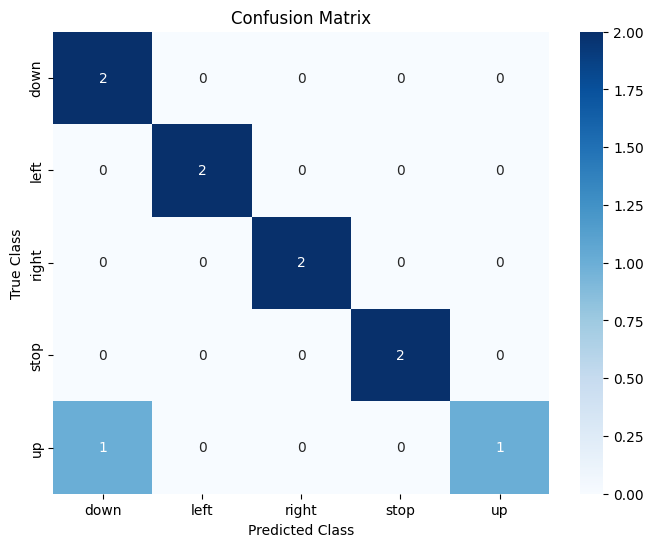

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# حساب الدقة على داتا الاختبار X_val
val_loss, val_accuracy = model.evaluate(X_val_padded, y_val)
print(f"\nValidation Accuracy: {val_accuracy * 100:.2f}%")

# استخراج التوقعات
y_pred_probs = model.predict(X_val_padded)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# طباعة التقرير الشامل باستخدام المتغير CLASS_NAMES اللي انت عرفته
print("\n--- Classification Report ---")
print(classification_report(y_val, y_pred_classes, target_names=CLASS_NAMES))

# رسم مصفوفة الارتباك
cm = confusion_matrix(y_val, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

In [20]:
import pickle

# 1. حفظ الموديل
model.save('voice_control_blstm_model.keras')
print("تم حفظ الموديل بنجاح (voice_control_blstm_model.keras)")

# 2. حفظ الـ Tokenizer
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("تم حفظ الـ Tokenizer بنجاح (tokenizer.pickle)")

# 3. حفظ الـ Label Encoder (المتغير بتاعك اسمه LB)
with open('label_encoder.pickle', 'wb') as handle:
    pickle.dump(LB, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("تم حفظ الـ Label Encoder بنجاح (label_encoder.pickle)")

تم حفظ الموديل بنجاح (voice_control_blstm_model.keras)
تم حفظ الـ Tokenizer بنجاح (tokenizer.pickle)
تم حفظ الـ Label Encoder بنجاح (label_encoder.pickle)


In [24]:
import numpy as np

# حد الثقة: تقدر تعليه أو تقلله (هنا مظبوط على 70%)
CONFIDENCE_THRESHOLD = 0.98

def test_model_predictions(texts, true_labels, num_samples=5, dataset_type="Test"):
    print(f"\n{'='*40}")
    print(f"--- اختبار عينات عشوائية من داتا الـ {dataset_type} ---")
    print(f"{'='*40}")
    
    # اختيار أرقام عشوائية لسحب عينات من الداتا
    random_indices = np.random.choice(len(texts), num_samples, replace=False)
    
    for idx in random_indices:
        text = texts[idx]
        
        # استرجاع اسم الكلاس الحقيقي من الـ Label Encoder
        true_label_idx = true_labels[idx] 
        true_intent = LB.inverse_transform([true_label_idx])[0]
        
        # 1. تجهيز النص (Tokenization & Padding)
        seq = tokenizer.texts_to_sequences([text])
        padded = pad_sequences(seq, maxlen=max_length, padding='post')
        
        # 2. التوقع (بيطلع مصفوفة احتمالات لكل الكلاسات)
        prediction_probs = model.predict(padded, verbose=0)[0]
        
        # 3. استخراج أعلى نسبة وأعلى كلاس
        max_prob = np.max(prediction_probs)
        predicted_class_idx = np.argmax(prediction_probs)
        
        # 4. تطبيق شرط الثقة (الـ Threshold)
        if max_prob >= CONFIDENCE_THRESHOLD:
            predicted_intent = LB.inverse_transform([predicted_class_idx])[0]
        else:
            predicted_intent = "unknown"
            
        # 5. طباعة النتائج
        print(f"🗣️ النص المدخل     : '{text}'")
        print(f"✅ النية الحقيقية   : {true_intent}")
        print(f"🤖 النية المتوقعة   : {predicted_intent}")
        print(f"📊 نسبة الثقة      : {max_prob * 100:.2f}%")
        print("-" * 40)

# ==========================================
# 1. تجربة 5 عينات من داتا التدريب (Training)
# ==========================================
test_model_predictions(train_texts, y_train, num_samples=5, dataset_type="Training")

# ==========================================
# 2. تجربة 5 عينات من داتا الاختبار (Validation/Testing)
# ==========================================
test_model_predictions(val_texts, y_val, num_samples=5, dataset_type="Validation")

# ==========================================
# 3. اختبار نصوص خارجية لاختبار الـ Unknown
# ==========================================
print(f"\n{'='*40}")
print("--- اختبار نصوص خارجية (يجب أن تكون unknown) ---")
print(f"{'='*40}")

out_of_scope_texts = ["افتح الباب لو سمحت", "عامل ايه النهاردة", "امشي يمين"]

for text in out_of_scope_texts:
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_length, padding='post')
    
    prediction_probs = model.predict(padded, verbose=0)[0]
    max_prob = np.max(prediction_probs)
    predicted_class_idx = np.argmax(prediction_probs)
    
    if max_prob >= CONFIDENCE_THRESHOLD:
        predicted_intent = LB.inverse_transform([predicted_class_idx])[0]
    else:
        predicted_intent = "unknown"
        
    print(f"🗣️ النص المدخل     : '{text}'")
    print(f"🤖 النية المتوقعة   : {predicted_intent}")
    print(f"📊 نسبة الثقة      : {max_prob * 100:.2f}%")
    print("-" * 40)


--- اختبار عينات عشوائية من داتا الـ Training ---
🗣️ النص المدخل     : 'لا تتحرك'
✅ النية الحقيقية   : stop
🤖 النية المتوقعة   : stop
📊 نسبة الثقة      : 99.99%
----------------------------------------
🗣️ النص المدخل     : 'يا كرسي ارجع للخلف'
✅ النية الحقيقية   : down
🤖 النية المتوقعة   : down
📊 نسبة الثقة      : 99.30%
----------------------------------------
🗣️ النص المدخل     : 'يمن'
✅ النية الحقيقية   : right
🤖 النية المتوقعة   : right
📊 نسبة الثقة      : 99.96%
----------------------------------------
🗣️ النص المدخل     : 'يا كرسي امشي لورا'
✅ النية الحقيقية   : down
🤖 النية المتوقعة   : down
📊 نسبة الثقة      : 98.79%
----------------------------------------
🗣️ النص المدخل     : 'سر يمين'
✅ النية الحقيقية   : right
🤖 النية المتوقعة   : right
📊 نسبة الثقة      : 99.99%
----------------------------------------

--- اختبار عينات عشوائية من داتا الـ Validation ---
🗣️ النص المدخل     : 'اجري قدام'
✅ النية الحقيقية   : up
🤖 النية المتوقعة   : up
📊 نسبة الثقة      : 99.98%
-----------